  ## Toxic Comment Filtering for Live Gaming Chat¶
Data Science Internship Project — Multi-Label Toxicity Classifier
Goal: flag live gaming-chat messages as one or more of spam, insult, profanity, hate_speech, or non_toxic, assign a 0–5 severity score, and recommend a moderation action (no action / soft flag / warning / mute / auto-ban).

Pipeline: load data -> clean informal chat text -> TF-IDF features -> One-vs-Rest Logistic Regression (multi-label) -> severity scoring -> moderation-action mapping -> test on a simulated live chat feed.



### Overview

 The brief references the Kaggle Jigsaw Toxic Comment Classification dataset. This sandbox has no network access to Kaggle, and the real Jigsaw labels (toxic, severe_toxic, obscene, threat, insult, identity_hate) don't include spam, which matters a lot for gaming chat. So this notebook trains on a synthetic, template-based gaming-chat dataset (data/gaming_chat_dataset.csv) that mirrors the project's five target categories, so the whole pipeline can be built and demonstrated end to end. Section 8 explains exactly how to swap in the real Jigsaw data once you download it from Kaggle yourself — the rest of the notebook (cleaning, model, scoring, moderation logic).

## 1. Important Libaries

In [6]:
import sys, os, pickle
sys.path.insert(0, os.path.abspath("."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, precision_score, confusion_matrix

from preprocessing import clean_text, SLANG_DICT
from model_utils import LABELS, SEVERITY_WEIGHTS, MODERATION_THRESHOLDS, compute_severity, score_to_action, predict_message

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)
print("Labels:", LABELS)

Labels: ['spam', 'insult', 'profanity', 'hate_speech', 'non_toxic']


## 2. Load Dataset

Columns: **message** (raw chat text) + one binary column per category. A
message can be positive on more than one column at once — that's the
**multi-label** part of the task (e.g. an insult that is also profane).

In [8]:
df = pd.read_csv(r"D:\programe\Documents\Data Science Project\gaming_chat_dataset.csv")

In [9]:
df.head(10)

,id,message,spam,insult,profanity,hate_speech,non_toxic
0,1,"ur accent is disgusting, go play somewhere else",0,1,0,1,0
1,2,uninstall the game you're useless in the game,0,1,0,0,0
2,3,let's queue up again in five lol,0,0,0,0,1
3,4,"you're a complete noob, go practice 😂",0,1,1,0,0
4,5,thanks 4 the heal that saved me in the lobby,0,0,0,0,1
5,6,"you're pathetic, that was awful",0,1,1,0,0
6,7,"check out my stream, follow follow follow lol",1,0,0,0,0
7,8,click here to claim your reward before it expires 😂,1,0,0,0,0
8,9,"go back 2 where u came from, we don't want u here",0,1,0,1,0
9,10,bro you're such a loser at this game in that round lol,0,1,1,0,0


In [10]:
print("shape", df.shape)

shape (677, 7)


## 3. Class distribution

Each bar contain the count of messages.

C:\Users\user\AppData\Local\Temp\ipykernel_13852\863806095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Blues")


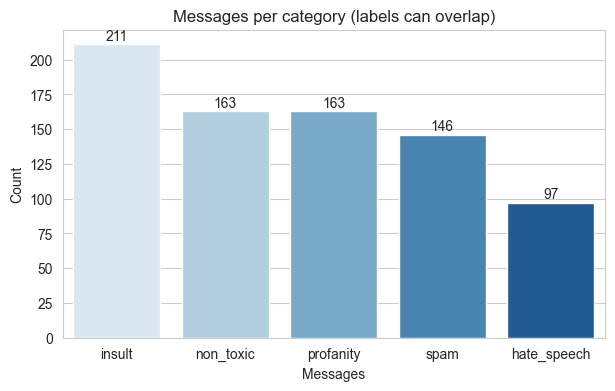

In [11]:
counts = df[LABELS].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=counts.index, y=counts.values, palette="Blues")
plt.title("Messages per category (labels can overlap)")
plt.ylabel("Count")
plt.xlabel("Messages")
for i, v in enumerate(counts.values):
    plt.text(i, v + 3, str(v), ha="center")
plt.show()

## 3. Preprocessing

Gaming chat is short, informal(`u`, `gg`, `wtf`,`brb`..) plus emoji and links. **preprocessing.py** applies, in order:

1. Lowercase.
2. Remove URLs.
3. Remove emojis.
4. Expand standard english contractions (`don't` → `do not`) via the
   `contractions` library.
5. Expand gaming/chat slang using a custom dictionary(`SLANG_DICT`).
6. Strip punctuation and collapse extra whitespace.

In [12]:
# Its is a simple example of its:

examples = ["wtf bro, don't do that again lol \U0001F92C"]

for e in examples:
    print(f"{e!r}\n  ->{clean_text(e)!r}\n")


"wtf bro, don't do that again lol 🤬"
  ->'what the heck bro do not do that again laughing'



In [13]:
df["clean_message"] = df["message"].apply(clean_text)
df[["message", "clean_message"]].sample(8, random_state=1)

,message,clean_message
92,who's up 4 one more game in this match,who is up 4 one more game in this match
148,buddy gg well played everyone 🤬,buddy good game well played everyone
159,free robux generator click now working 2026 in this server,free robux generator click now working 2026 in this server
460,DM me 2 buy ur account boosted fast in ranked,direct message me 2 buy you are account boosted fast in ranked
453,you're such a loser at this game in that round,you are such a loser at this game in that round
104,how r u this bad seriously 🤬,how are you this bad seriously
172,kid cheap boosting service dm now limited slots,kid cheap boosting service direct message now limited slots
481,"you're pathetic, that was awful lol",you are pathetic that was awful laughing


## 4. Features extraction TF - IDF

- Word-level TF-IDF with unigrams + bigrams. 
- Bigrams help catch short toxic
phrases ("go back", "so bad") that single words alone would miss.
- And also train_test_split where data train and tested. Its should be train_shape: (541, 769) and test_shape: (136, 769).

In [14]:
X = df["clean_message"]
y = df[LABELS]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42, stratify=df["non_toxic"])

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Train_shape:", X_train_vec.shape, "Test_shape:", X_test_vec.shape)

Train_shape: (541, 769) Test_shape: (136, 769)


## 5. Train the multi-label classifier (traditional ML)

**LogisticRegression** wrapped in **MultiOutputClassifier** trains one
binary classifier per label — a simple, fast, interpretable baseline that's
a good fit for a small and medium chat-moderation dataset (as requested:
"traditional ML", not deep learning).

In [15]:
base_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
model = MultiOutputClassifier(base_clf)
model.fit(X_train_vec, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,LogisticRegre...max_iter=1000)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary ` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights invers

Our Model is trainded.

## 6. Evaluate

This custom label set doesn't have a **severe_toxic** column — **hate_speech** is the
closest equivalent (the most severe category), so that's the one checked
against the 80% bar.

In [16]:
Y_pred = model.predict(X_test_vec)

print(classification_report(y_test, Y_pred, target_names=LABELS, zero_division=0))

hate_idx = LABELS.index("hate_speech")
hate_precision = precision_score(y_test.iloc[:, hate_idx], Y_pred[:, hate_idx], zero_division=0)
status = "PASS" if hate_precision >= 0.80 else "FAIL"
print(f"hate_speech precision (severe-toxic equivalent): {hate_precision:.3f}  -> requirement >0.80: {status}")

              precision    recall  f1-score   support

        spam       1.00      1.00      1.00        28
      insult       0.84      1.00      0.91        41
   profanity       0.80      0.85      0.82        33
 hate_speech       1.00      1.00      1.00        16
   non_toxic       1.00      1.00      1.00        33

   micro avg       0.91      0.97      0.94       151
   macro avg       0.93      0.97      0.95       151
weighted avg       0.91      0.97      0.94       151
 samples avg       0.94      0.98      0.95       151

hate_speech precision (severe-toxic equivalent): 1.000  -> requirement >0.80: PASS


## 6.1 Confusion Matrix Per Label.

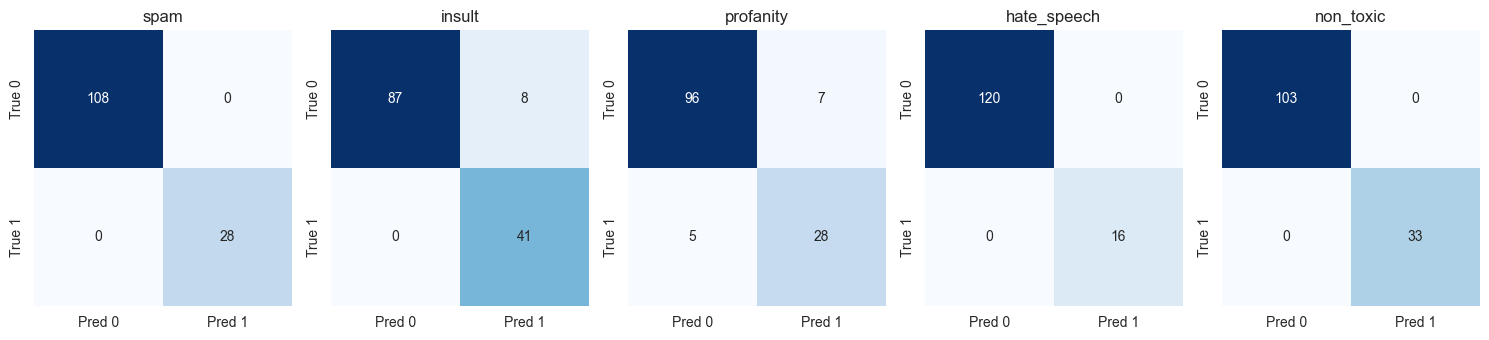

In [17]:
fig, axes = plt.subplots(1, len(LABELS), figsize=(3*len(LABELS), 3.5))
for i, label in enumerate(LABELS):
    cm = confusion_matrix(y_test.iloc[:, i], Y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i],
                xticklabels=["Pred 0","Pred 1"], yticklabels=["True 0","True 1"])
    axes[i].set_title(label)
plt.tight_layout()
plt.show()

## 7. Severity scoring (0–5) and moderation actions

Each category has a **severity weight** reflecting how serious it is at
maximum confidence:

| Category | Weight |
|---|---|
| non_toxic | 0 |
| spam | 2 |
| profanity | 3 |
| insult | 4 |
| hate_speech | 5 |

For a message, only categories the model actually flags (probability ≥ 0.5)
are considered. **Severity = weight × probability of the flagged category
with the highest such value**, rounded to the nearest whole number and
capped to 0–5. This rewards both *how bad* a category is and *how confident*
the model is.

In [18]:
thresholds_df = pd.DataFrame(MODERATION_THRESHOLDS, columns=["min_severity", "max_severity", "action"])
thresholds_df

,min_severity,max_severity,action
0,0,0,No action - message is clean
1,1,2,Soft flag / log only - monitor user
2,3,3,Warning issued to user
3,4,4,"Mute user (temporary, e.g. 10 min) + remove message"
4,5,5,Auto-ban / escalate to human moderator immediately


## 8. Test on a simulated live chat feed

This mimics a real-time moderation bot reading messages one by one.

In [20]:
live_feed = pd.read_csv("D:\programe\Documents\Data Science Project\live_chat_feed.csv")
live_feed.head()

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\user\AppData\Local\Temp\ipykernel_13852\3248087515.py:1: SyntaxWarning: invalid escape sequence '\p'
  live_feed = pd.read_csv("D:\programe\Documents\Data Science Project\live_chat_feed.csv")


,user,message
0,Player_101,gg wp everyone that was a great match!
1,Player_204,"u are so bad at this game, uninstall pls"
2,Player_309,FREE VBUCKS!! click the link in my bio now
3,Player_117,wtf bro that lag was so annoying today
4,Player_450,can someone help me find the objective on this map


In [21]:
results = []
for _, row in live_feed.iterrows():
    r = predict_message(row["message"], clean_text, vectorizer, model)
    results.append({
        "user": row["user"],
        "message": row["message"],
        "predicted_labels": ", ".join(r["predicted_labels"]),
        "severity": r["severity"],
        "action": r["action"],
    })

detection_log = pd.DataFrame(results)
detection_log

,user,message,predicted_labels,severity,action
0,Player_101,gg wp everyone that was a great match!,non_toxic,0,No action - message is clean
1,Player_204,"u are so bad at this game, uninstall pls","insult, profanity",4,"Mute user (temporary, e.g. 10 min) + remove message"
2,Player_309,FREE VBUCKS!! click the link in my bio now,spam,2,Soft flag / log only - monitor user
3,Player_117,wtf bro that lag was so annoying today,profanity,3,Warning issued to user
4,Player_450,can someone help me find the objective on this map,non_toxic,0,No action - message is clean
5,Player_233,"you're trash, just quit already noob",insult,4,"Mute user (temporary, e.g. 10 min) + remove message"
6,Player_567,"people like you don't belong on this server, go back","insult, hate_speech",5,Auto-ban / escalate to human moderator immediately
7,Player_089,"thx for the heal, that clutch save",non_toxic,0,No action - message is clean
8,Player_312,add me on discord for free skins!!!,spam,2,Soft flag / log only - monitor user
9,Player_178,holy crap that was such a close round,profanity,3,Warning issued to user


In [25]:
detection_log.to_csv(r"C:\Users\user\Desktop\env_name\Toxic_Comment_Filtering_Submission\toxic_project\logs.csv", index=False)
print("Its Saved")

Its Saved


## 9. Visual log — detections by type and severity.

C:\Users\user\AppData\Local\Temp\ipykernel_13852\1241131413.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues", ax=axes[0]) # Bar plot.
C:\Users\user\AppData\Local\Temp\ipykernel_13852\1241131413.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="severity", data=detection_log, palette="Blues", order=range(0,6), ax=axes[1])# Count plot.


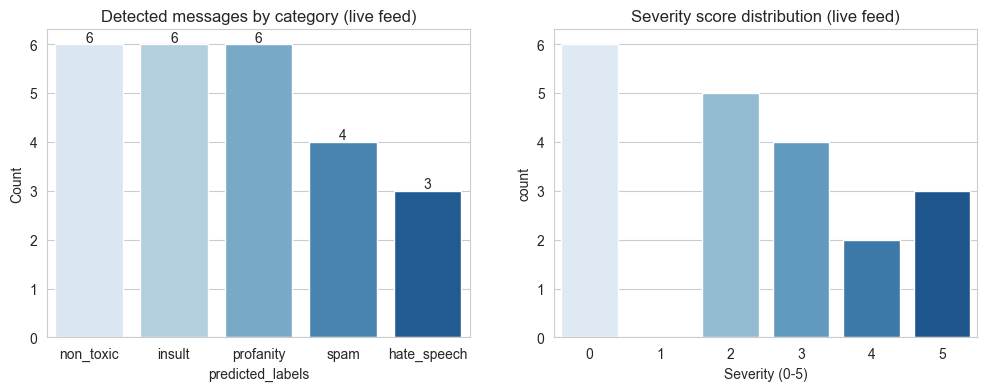

In [26]:
all_labels = detection_log["predicted_labels"].str.split(", ").explode()
label_counts = all_labels.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=label_counts.index, y=label_counts.values, palette="Blues", ax=axes[0]) # Bar plot.
axes[0].set_title("Detected messages by category (live feed)")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 0.05, str(v), ha="center")

sns.countplot(x="severity", data=detection_log, palette="Blues", order=range(0,6), ax=axes[1])# Count plot.
axes[1].set_title("Severity score distribution (live feed)")
axes[1].set_xlabel("Severity (0-5)")
plt.show()

In [27]:
def highlight_action(val):
    color_map = {
        "No action - message is clean": "background-color: #d9f2d9",
        "Soft flag / log only - monitor user": "background-color: #fff6cc",
        "Warning issued to user": "background-color: #ffe0b3",
        "Mute user (temporary, e.g. 10 min) + remove message": "background-color: #ffb3b3",
        "Auto-ban / escalate to human moderator immediately": "background-color: #ff8080",
    }
    return color_map.get(val, "")

detection_log.style.map(highlight_action, subset=["action"])

,user,message,predicted_labels,severity,action
0,Player_101,gg wp everyone that was a great match!,non_toxic,0,No action - message is clean
1,Player_204,"u are so bad at this game, uninstall pls","insult, profanity",4,"Mute user (temporary, e.g. 10 min) + remove message"
2,Player_309,FREE VBUCKS!! click the link in my bio now,spam,2,Soft flag / log only - monitor user
3,Player_117,wtf bro that lag was so annoying today,profanity,3,Warning issued to user
4,Player_450,can someone help me find the objective on this map,non_toxic,0,No action - message is clean
5,Player_233,"you're trash, just quit already noob",insult,4,"Mute user (temporary, e.g. 10 min) + remove message"
6,Player_567,"people like you don't belong on this server, go back","insult, hate_speech",5,Auto-ban / escalate to human moderator immediately
7,Player_089,"thx for the heal, that clutch save",non_toxic,0,No action - message is clean
8,Player_312,add me on discord for free skins!!!,spam,2,Soft flag / log only - monitor user
9,Player_178,holy crap that was such a close round,profanity,3,Warning issued to user


## 10. Mitigation strategy summary

| Severity | Trigger examples | Action | Rationale |
|---|---|---|---|
| 0 | Clean chat | No action | Normal conversation, no moderation cost |
| 1–2 | Spam links, mild profanity | Soft flag / log only | Low harm; track repeat patterns without disrupting play |
| 3 | Insults, repeated profanity | Warning issued to user | Give the player a chance to self-correct |
| 4 | Sustained insults / harassment | Temporary mute + message removed | Protect other players immediately, but stay reversible |
| 5 | Hate speech / severe harassment | Auto-ban + escalate to human moderator | Zero-tolerance category; human review confirms before permanent action |

## Design principles used:
- **Escalating response** - Action severity scales with predicted severity, not a single fixed penalty.
- **Human-in-the-loop for the worst cases** - Severity 5 auto-bans are paired with a mandatory human review queue rather than being fully automatic and irreversible, to control false-positive risk.
- **Repeat-offense tracking** (future work) - A real system would also weight a user's recent history, not just the single message.